# 08. fashion_mnist + vit

This notebook runs only **fashion_mnist + vit** using locally prepared datasets. It uses the faster 5-corruption setup: gaussian_noise, motion_blur, fog, brightness, jpeg_compression.

In [1]:
import sys, subprocess
REQUIRED_PACKAGES = ['setuptools<81', 'timm>=1.0.15', 'imagecorruptions==1.1.2', 'datasets>=2.21.0', 'umap-learn>=0.5.6', 'scikit-learn>=1.5.1', 'scikit-image<0.20', 'pandas>=2.0.0', 'matplotlib>=3.8.0', 'tqdm>=4.66.0', 'kaggle>=1.7.4.5']
subprocess.check_call([sys.executable, "-m", "pip", "install", *REQUIRED_PACKAGES])
print("Package installation complete.")


Package installation complete.


In [2]:
from pathlib import Path
import sys
import time
import os
from IPython.display import display
NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from assignment2_gpu_split_module import *


2026-03-21 01:28:36.688594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 01:28:36.765943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root: /data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04
Device: cuda
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU name: NVIDIA H100 NVL
cifar10              -> https://www.cs.toronto.edu/~kriz/cifar.html
fashion_mnist        -> https://github.com/zalandoresearch/fashion-mnist
imagenet100_hf       -> https://huggingface.co/datasets/clane9/imagenet-100
imagenet100_kaggle   -> https://www.kaggle.com/datasets/ambityga/imagenet100
imagecorruptions     -> https://github.com/bethgelab/imagecorruptions
robustness_repo      -> https://github.com/hendrycks/robustness


- input size: `224`
- policy K values: `1, 3, 5, 10, 15`
- backbones: `vgg16_bn, resnet50, convnext_tiny, vit_base_patch16_224`

In [3]:
PAIR_DATASET = "fashion_mnist"
PAIR_MODEL = "vit"
TARGET_BATCH_SIZE = 200
IMAGENET100_SOURCE = "local"
IMAGENET100_ROOT = ROOT / "data" / "imagenet100"
TRAIN_PRETRAINED = False
USE_TORCH_COMPILE = True
RUN_REQUIRED_VISUALS = True
RUN_OPTIONAL_FEATURE_PERTURBATION = False
NUM_WORKERS = min(12, os.cpu_count() or 4)

print("PAIR_DATASET =", PAIR_DATASET)
print("PAIR_MODEL =", PAIR_MODEL)
print("TARGET_BATCH_SIZE =", TARGET_BATCH_SIZE)
print("IMAGENET100_ROOT =", IMAGENET100_ROOT)
print("USE_TORCH_COMPILE =", USE_TORCH_COMPILE)
print("NUM_WORKERS =", NUM_WORKERS)
print("COMMON_CORRUPTIONS =", COMMON_CORRUPTIONS)


PAIR_DATASET = fashion_mnist
PAIR_MODEL = vit
TARGET_BATCH_SIZE = 200
IMAGENET100_ROOT = /data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/data/imagenet100
USE_TORCH_COMPILE = True
NUM_WORKERS = 12
COMMON_CORRUPTIONS = ['gaussian_noise', 'motion_blur', 'fog', 'brightness', 'jpeg_compression']


Auto batch-size probe succeeded with batch_size=200 | memory={'allocated_gb': 1.456, 'reserved_gb': 1.914, 'max_allocated_gb': 13.479}
Running single GPU pair: fashion_mnist + vit
Chosen batch size: 200
torch.compile enabled: True
num_workers: 12
torch.compile enabled for this run.
Epoch 1/25 | training...
Epoch 1/25 | clean validation...
Epoch 1/25 | corrupted validation over 5 corruption types...
  validating corruption: gaussian_noise
  validating corruption: motion_blur
  validating corruption: fog
  validating corruption: brightness
  validating corruption: jpeg_compression
{'epoch': 1, 'train_loss': 1.628553714354833, 'train_acc': 0.3861041666666667, 'lr': 0.0002988172051971717, 'time_sec': 47.421945571899414, 'val_acc__clean': 0.564, 'val_acc__gaussian_noise': 0.5370833333333334, 'val_acc__motion_blur': 0.5686666666666667, 'val_acc__fog': 0.1235, 'val_acc__brightness': 0.15475, 'val_acc__jpeg_compression': 0.5626666666666666, 'val_acc__corr_k1_s2': 0.5370833333333334, 'val_acc__

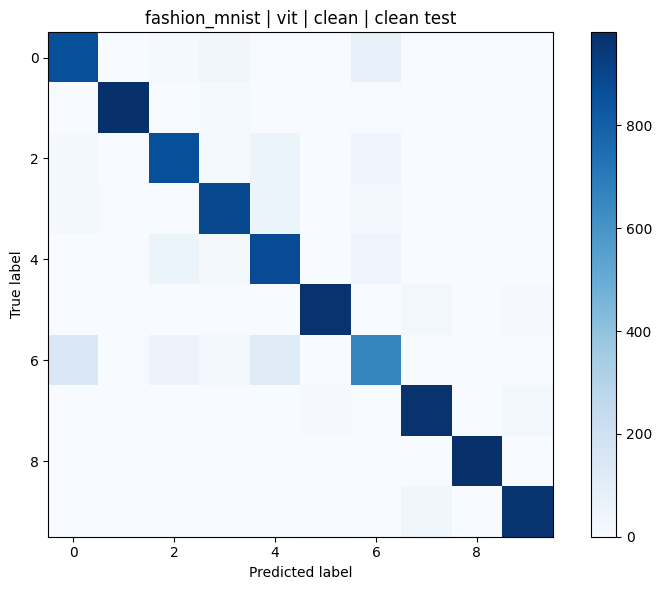

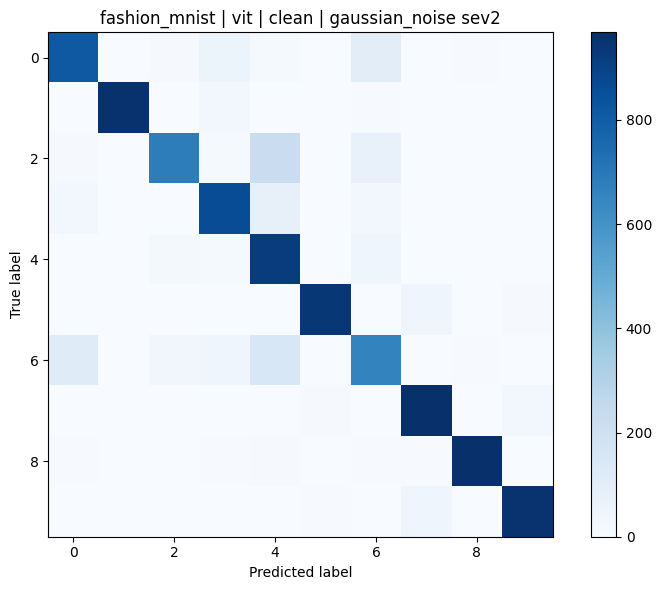

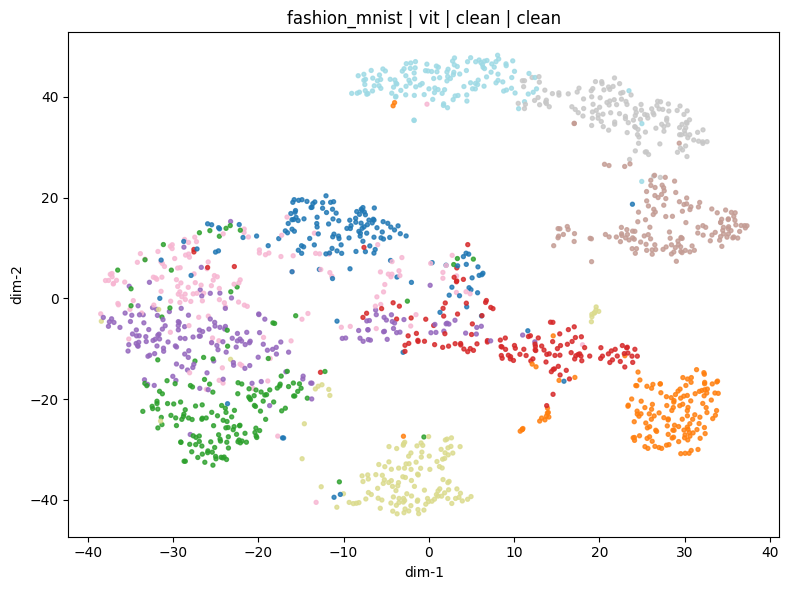

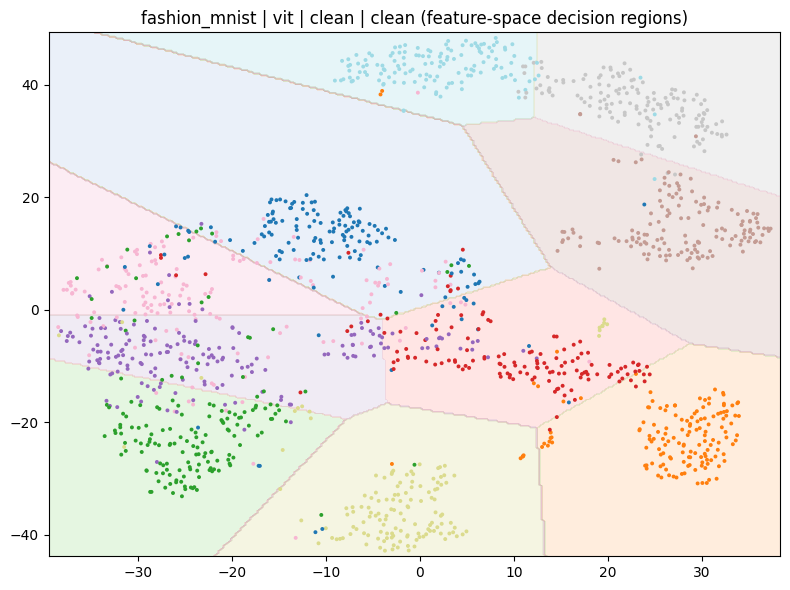

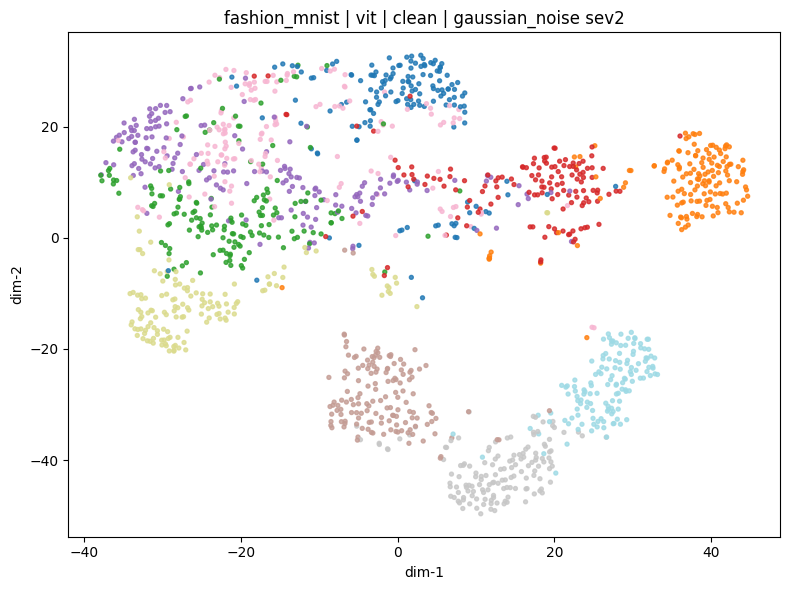

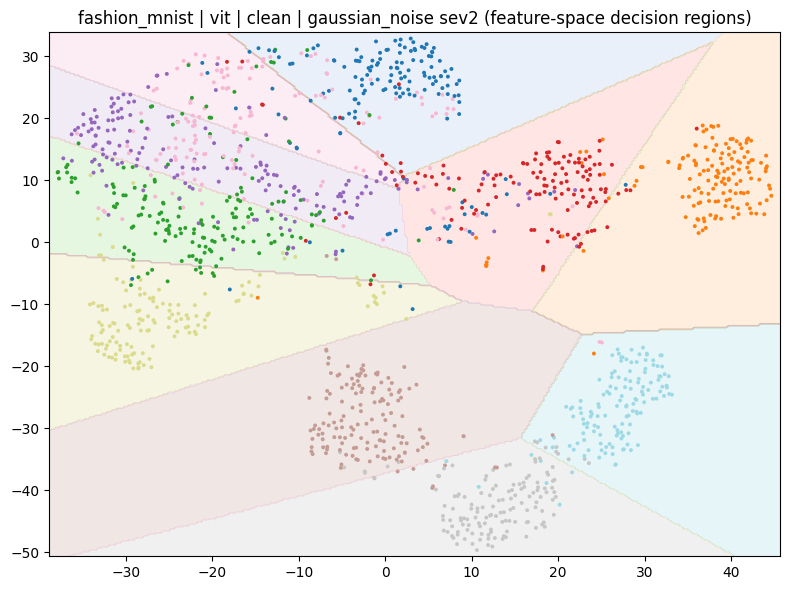

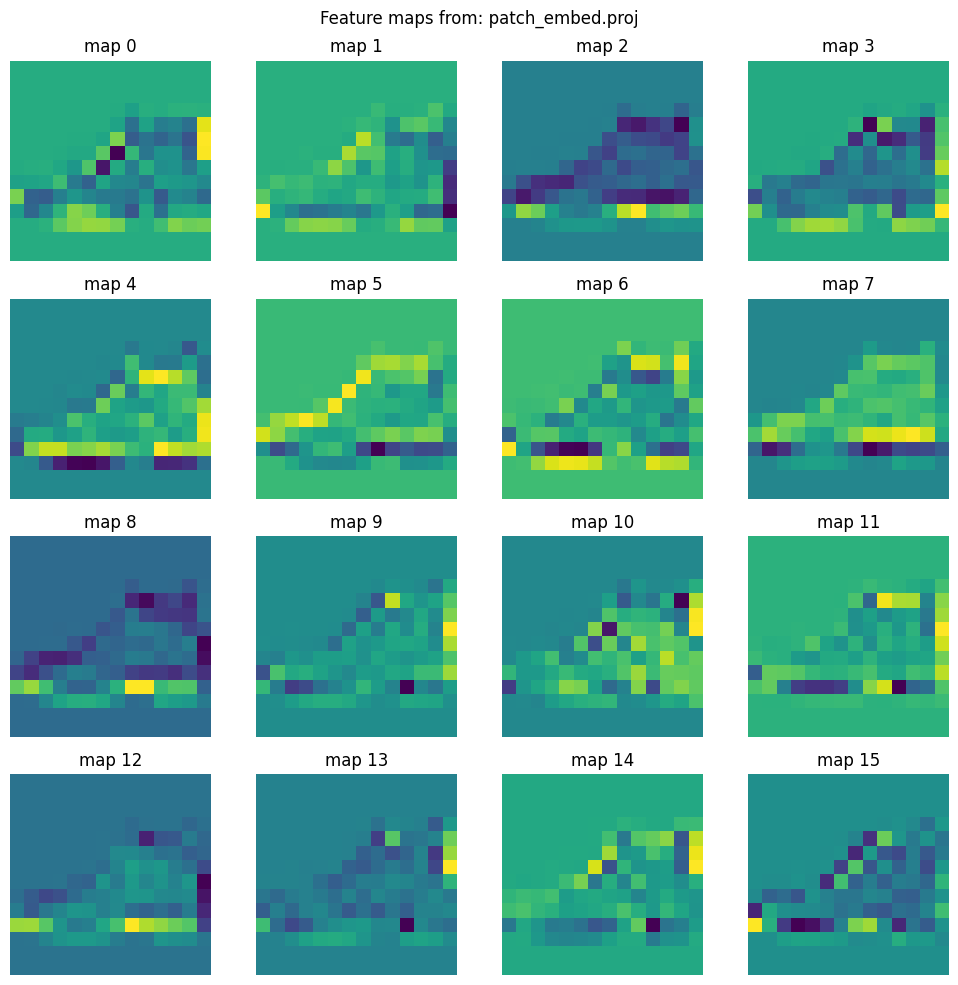

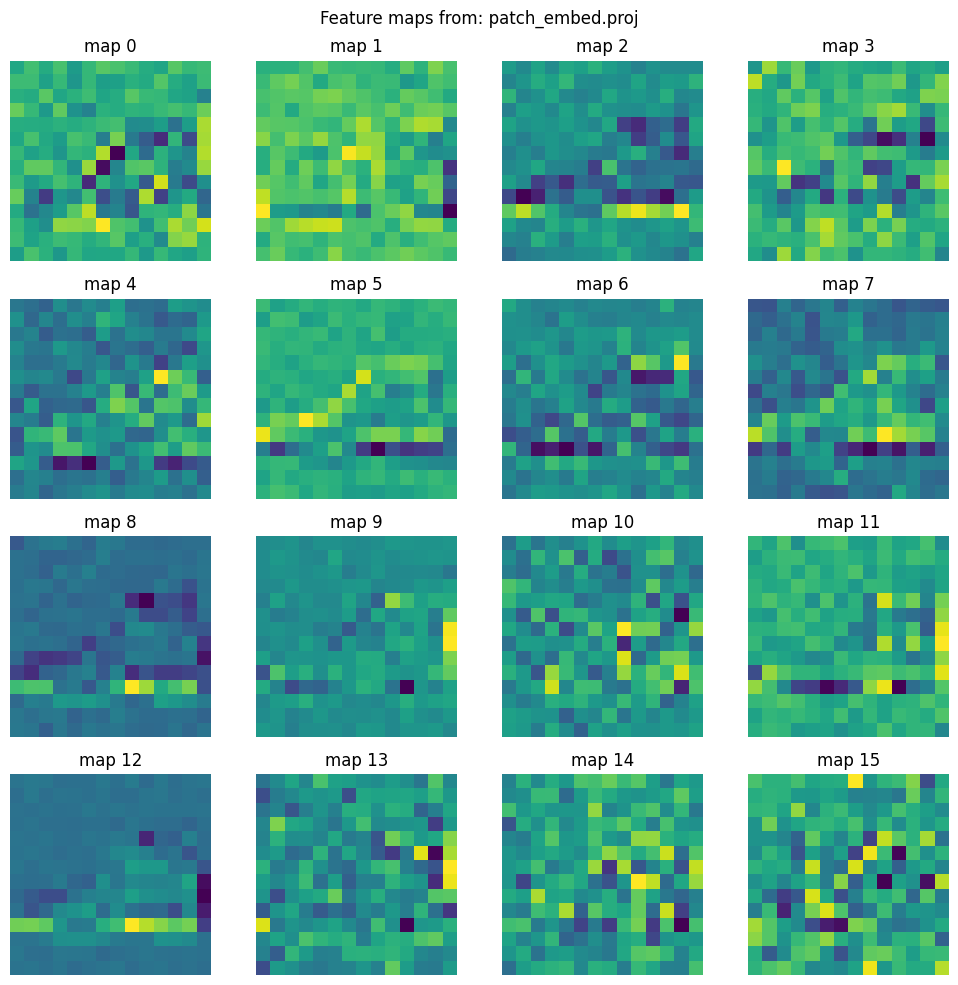

Saved plots to: /data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/plots/clean


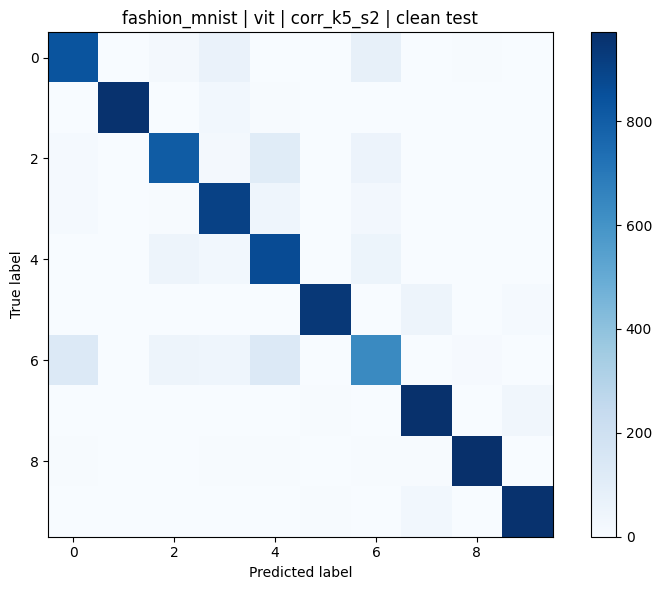

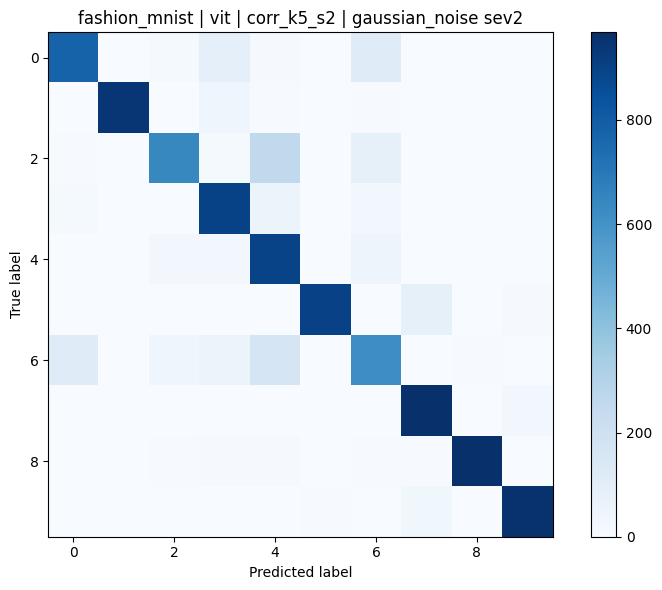

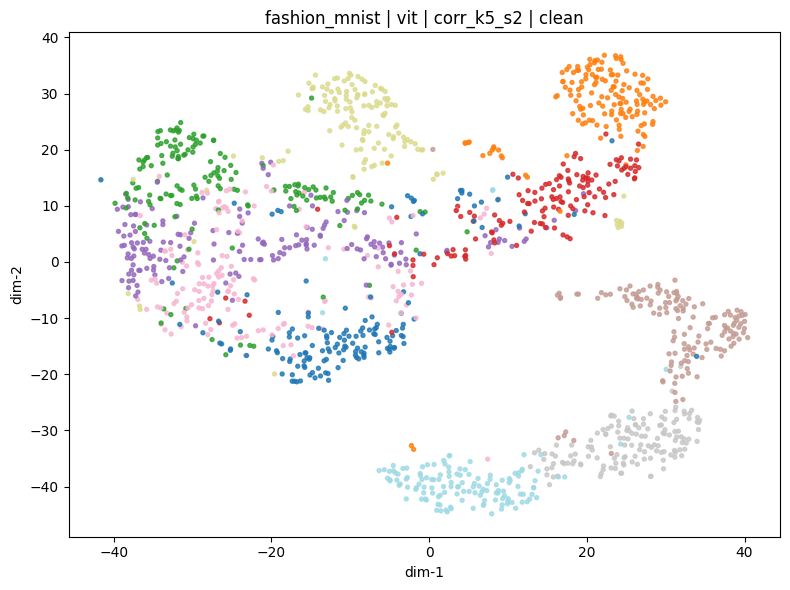

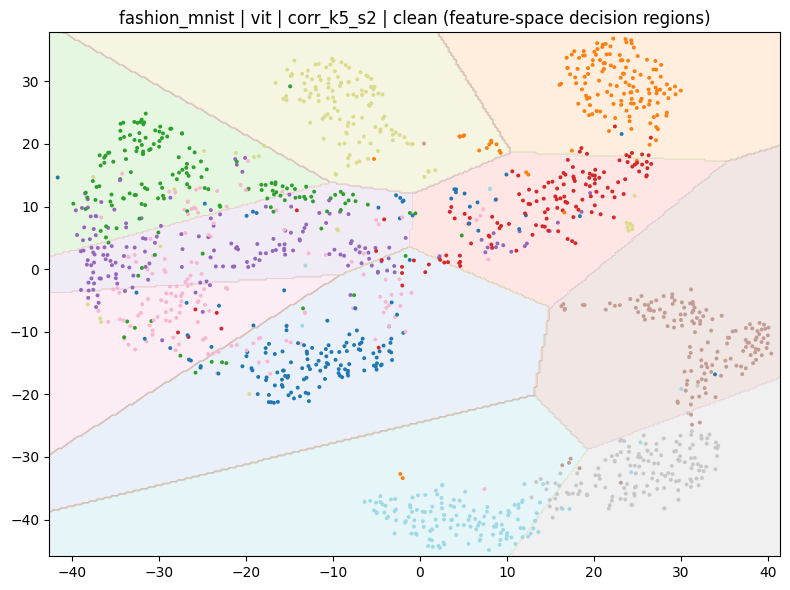

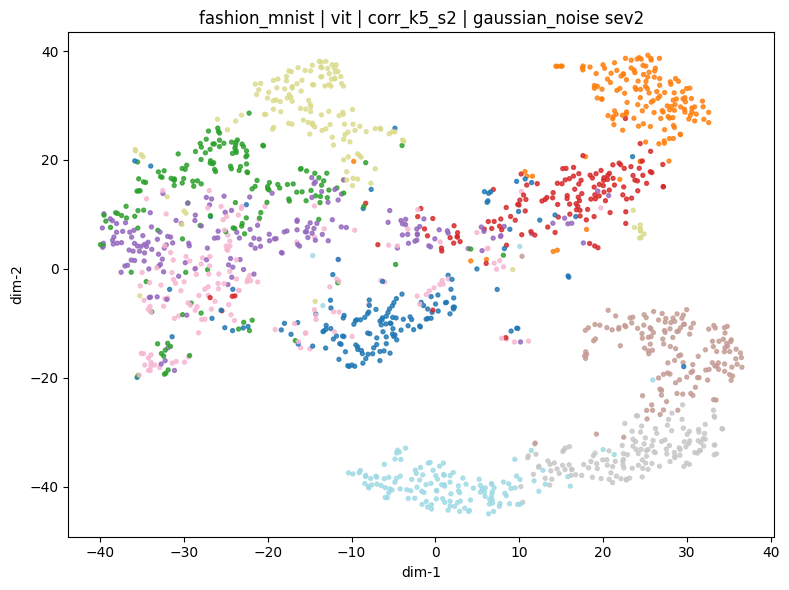

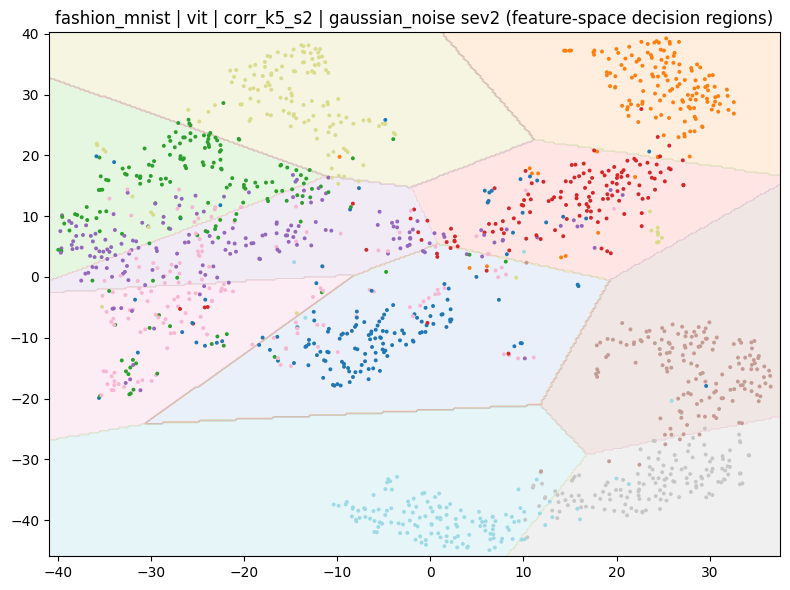

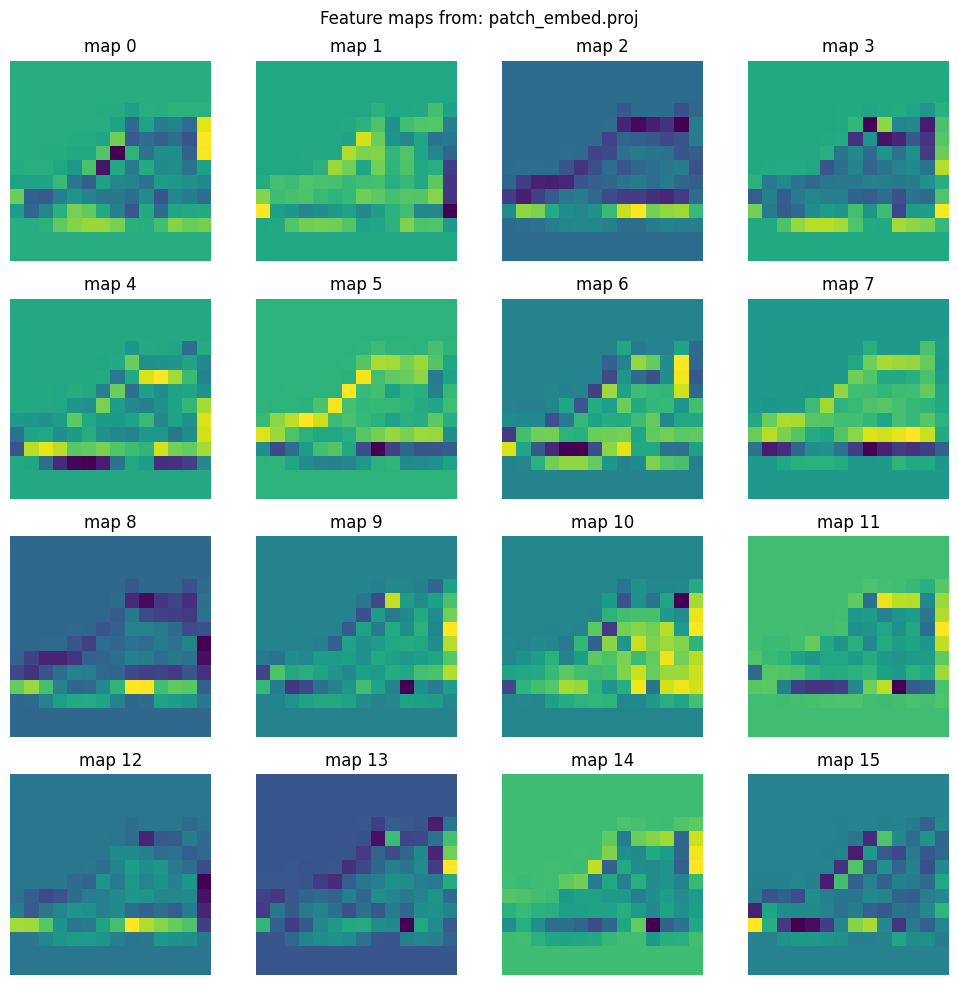

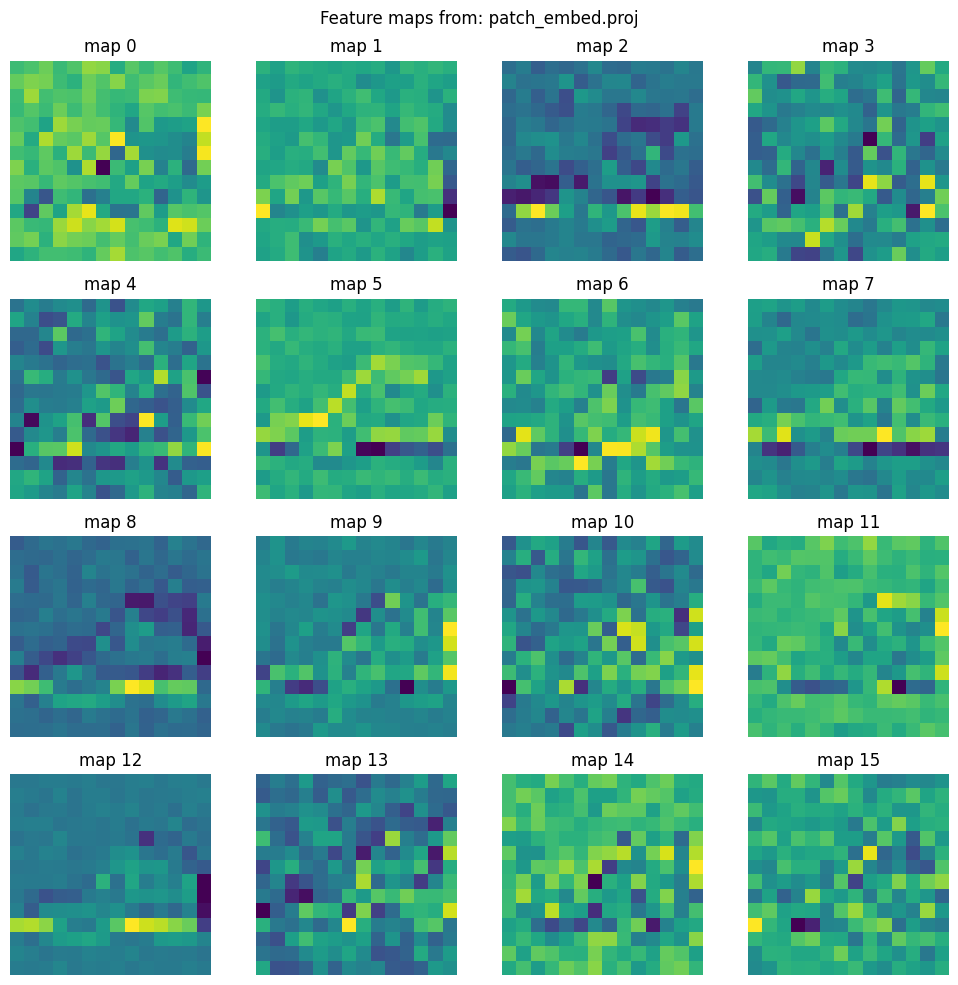

Saved plots to: /data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/plots/corr_k5_s2

Finished in 1.03 hours


,dataset,model,selector,selector_type,best_epoch,best_val_score,num_val_corruptions,val_corruption_names,val_corruption_severity,test_clean_acc,test_corrupt_mean_acc,robustness_gap,experiment_dir,checkpoint_path
0,fashion_mnist,vit,clean,clean,25,0.902750,0,,0,0.9001,0.67070,0.22940,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...
1,fashion_mnist,vit,corr_k1_s2,corrupt,24,0.877167,1,gaussian_noise,2,0.9006,0.67058,0.23002,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...
2,fashion_mnist,vit,corr_k3_s2,corrupt,23,0.655528,3,"gaussian_noise, motion_blur, fog",2,0.8974,0.67028,0.22712,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...
3,fashion_mnist,vit,corr_k5_s2,corrupt,18,0.676233,5,"gaussian_noise, motion_blur, fog, brightness, ...",2,0.8846,0.67250,0.21210,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...


,dataset,model,selector,selector_type,best_epoch,best_val_score,num_val_corruptions,val_corruption_names,val_corruption_severity,test_clean_acc,test_corrupt_mean_acc,robustness_gap,experiment_dir,checkpoint_path
0,fashion_mnist,vit,clean,clean,25,0.90275,0,,0,0.9001,0.6707,0.2294,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...


,dataset,model,selector,selector_type,best_epoch,best_val_score,num_val_corruptions,val_corruption_names,val_corruption_severity,test_clean_acc,test_corrupt_mean_acc,robustness_gap,experiment_dir,checkpoint_path
0,fashion_mnist,vit,corr_k5_s2,corrupt,18,0.676233,5,"gaussian_noise, motion_blur, fog, brightness, ...",2,0.8846,0.6725,0.2121,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...


,dataset,model,selector_clean_selector,selector_type_clean_selector,best_epoch_clean_selector,best_val_score_clean_selector,num_val_corruptions_clean_selector,val_corruption_names_clean_selector,val_corruption_severity_clean_selector,test_clean_acc_clean_selector,...,best_epoch_best_corrupt_selector,best_val_score_best_corrupt_selector,num_val_corruptions_best_corrupt_selector,val_corruption_names_best_corrupt_selector,val_corruption_severity_best_corrupt_selector,test_clean_acc_best_corrupt_selector,test_corrupt_mean_acc_best_corrupt_selector,robustness_gap_best_corrupt_selector,experiment_dir_best_corrupt_selector,checkpoint_path_best_corrupt_selector
0,fashion_mnist,vit,clean,clean,25,0.90275,0,,0,0.9001,...,18,0.676233,5,"gaussian_noise, motion_blur, fog, brightness, ...",2,0.8846,0.6725,0.2121,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...


,selector,plot_dir
0,clean,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...
1,corr_k5_s2,/data/Sajjan_Singh/cv_assign_04/cv_assign_04_g...


In [ ]:
# Mark the start time for the full experiment loop
run_start_time = time.time()

# Main function: passes all hyperparameters into the training/eval wrapper
result = run_single_pair_job(
    dataset_name=PAIR_DATASET,
    model_name=PAIR_MODEL,
    target_batch_size=TARGET_BATCH_SIZE,
    imagenet100_source=IMAGENET100_SOURCE,
    imagenet100_root=IMAGENET100_ROOT,
    train_pretrained=TRAIN_PRETRAINED,
    use_torch_compile=USE_TORCH_COMPILE,
    run_required_visuals=RUN_REQUIRED_VISUALS,
    run_optional_feature_perturbation=RUN_OPTIONAL_FEATURE_PERTURBATION,
    num_workers=NUM_WORKERS,
)

# Convert total runtime to hours (useful for the lab log)
elapsed_hours = (time.time() - run_start_time) / 3600.0
print(f"\nFinished in {elapsed_hours:.2f} hours")

# Render results tables in the notebook interface
display(result["summary_df"])           # Overall metrics (Acc, Loss, etc.)
display(result["clean_rows_df"])         # Results on standard (unmodified) data
display(result["best_corrupt_rows_df"])  # Robustness/OOD test results
display(result["comparison_df"])         # Model vs Model performance delta

# Check if visuals exist before trying to render plots/images
if not result["visuals_df"].empty:
    display(result["visuals_df"])

In [5]:
print("Saved files:")
print(Path(result["experiment_dir"]) / "selector_summary.csv")
print(Path(result["experiment_dir"]) / "pair_all_selectors.csv")
print(Path(result["experiment_dir"]) / "pair_clean_rows.csv")
print(Path(result["experiment_dir"]) / "pair_best_corrupt_rows.csv")
print(Path(result["experiment_dir"]) / "pair_clean_vs_best_corrupt_comparison.csv")


Saved files:
/data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/selector_summary.csv
/data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/pair_all_selectors.csv
/data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/pair_clean_rows.csv
/data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/pair_best_corrupt_rows.csv
/data/Sajjan_Singh/cv_assign_04/cv_assign_04_gpu_split_local_fast5/cv_assign_04_gpu_split_local_fast5/cv_assign_04/checkpoints/fashion_mnist_vit_seed42/pair_clean_vs_best_corrupt_comparison.csv
